In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

import pickle
import os

In [23]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,24,128,196,22.750888,90.694892,5.521467,110.431786,apple
1,7,144,197,23.849401,94.348150,6.133221,114.051249,apple
2,14,128,205,22.608010,94.589006,6.226290,116.039659,apple
3,8,120,201,21.186674,91.134357,6.321152,122.233323,apple
4,20,129,201,23.410447,91.699133,5.587906,116.077793,apple


In [24]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)

df.info()
df.describe()

print("\nMissing values:\n", df.isnull().sum())

Shape: (6596, 8)

Columns: Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6596 entries, 0 to 6595
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            6596 non-null   int64  
 1   P            6596 non-null   int64  
 2   K            6596 non-null   int64  
 3   temperature  6596 non-null   float64
 4   humidity     6596 non-null   float64
 5   ph           6596 non-null   float64
 6   rainfall     6596 non-null   float64
 7   label        6596 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 412.4+ KB

Missing values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [25]:
X = df.drop("label", axis=1)
y = df["label"]

In [26]:
le = LabelEncoder()
y = le.fit_transform(y)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 0.8144
Decision Tree Accuracy: 0.9856
Random Forest Accuracy: 0.9970
KNN Accuracy: 0.9583


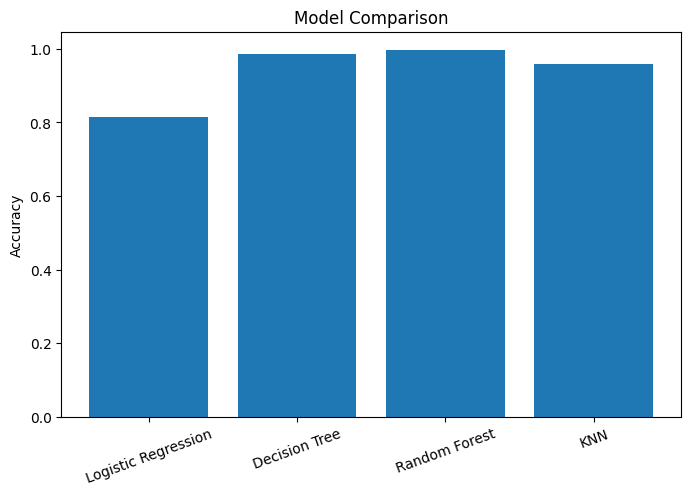

In [29]:
names = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(8,5))
plt.bar(names, scores)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

In [30]:
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

Best Model: Random Forest


In [31]:
rf_default = RandomForestClassifier()
print("Default Parameters:\n", rf_default.get_params())

Default Parameters:
 {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [32]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


In [33]:
default_model = RandomForestClassifier(random_state=42)
default_model.fit(X_train, y_train)

y_pred_default = default_model.predict(X_test)
default_acc = accuracy_score(y_test, y_pred_default)

print("Default Accuracy:", default_acc)

Default Accuracy: 0.996969696969697


In [34]:
tuned_model = random_search.best_estimator_

y_pred_tuned = tuned_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print("Tuned Accuracy:", tuned_acc)

Tuned Accuracy: 0.996969696969697


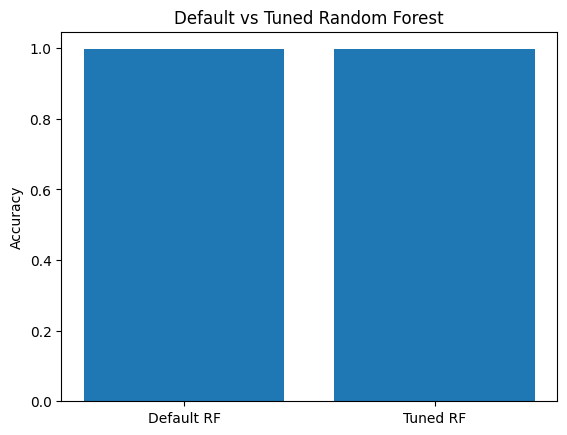

In [35]:
models = ["Default RF", "Tuned RF"]
scores = [default_acc, tuned_acc]

plt.bar(models, scores)
plt.ylabel("Accuracy")
plt.title("Default vs Tuned Random Forest")
plt.show()

In [36]:
final_model = tuned_model

In [37]:
y_pred = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Final Accuracy: 0.996969696969697

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        48
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00        25
           5       1.00      1.00      1.00        16
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00        10
           8       1.00      1.00      1.00         2
           9       1.00      1.00      1.00         8
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00        21
          12       1.00      1.00      1.00        14
          13       1.00      1.00      1.00        13
          14       1.00      1.00      1.00        44
          15       1.00      1.00      1.00        16
          16       1.0

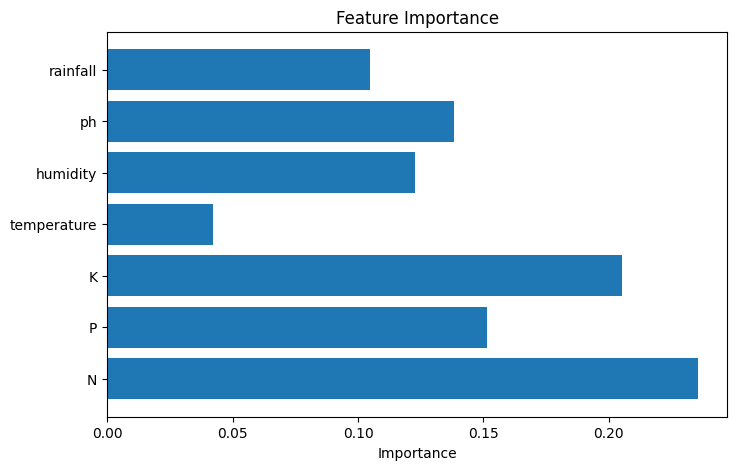

In [38]:
importance = final_model.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.xlabel("Importance")
plt.title("Feature Importance")
plt.show()

In [39]:
os.makedirs("../backend", exist_ok=True)

pickle.dump(final_model, open("../backend/model.pkl", "wb"))
pickle.dump(le, open("../backend/encoder.pkl", "wb"))

In [40]:
sample = [[90, 40, 40, 25, 80, 6.5, 200]]

pred = final_model.predict(sample)

print("Predicted Crop:", le.inverse_transform(pred)[0])

Predicted Crop: jute


c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [41]:
probs = final_model.predict_proba(sample)
confidence = max(probs[0])

print("Confidence:", confidence)

Confidence: 0.48975793650793653


c:\Users\Jaya Jha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
